# Wind Farm Yaw Control via PPO (Proximal Policy Optimization)

This notebook trains a PPO agent to maximize total power output by controlling the yaw angles of 3 turbines in the `Turb3_Row1_Floris` environment.

**Baselines to beat** (Scenario 2 - random wind conditions):
- Note: Sc.1 fixed-wind baselines (228/232) do not apply here; Sc.2 rewards vary with sampled wind conditions.
- WFCRL ([arXiv:2501.13592](https://arxiv.org/abs/2501.13592)), Table 7 - `Turb3_Row1_Floris` FLORIS, 200k steps:
  - **IPPO (trained Sc.2, eval Sc.2): 406.0 +/- 10.5** <- target to beat
  - MAPPO (trained Sc.2, eval Sc.2): 372.4 +/- 15.5
  - IPPO (trained Sc.1, eval Sc.2): 354.8 +/- 14.4
  - MAPPO (trained Sc.1, eval Sc.2): 345.1 +/- 12.6

**Algorithm**: PPO with clipped surrogate objective, GAE(lambda), and shared Actor-Critic backbone.

In [73]:
# If you wanna run on Colab:
# !pip install -q git+https://github.com/ifpen/wfcrl-env.git tabpfn-client torch-geometric python-dotenv "numpy==2.0.2" "scipy==1.16.3" "scikit-learn==1.6.1"

In [74]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

from wfcrl import environments as envs

sns.set_theme(style="whitegrid")
SEED = 13
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="floris")


In [75]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Environment Setup

In [ ]:
env = envs.make(
    "Turb3_Row1_Floris",
    max_num_steps=2048,
    controls={"yaw": (-45, 45, 5)},  # range in degrees, step degrees per action
    continuous_control=True,
    log=True,
)

N_TURBINES = env.num_turbines
print(f"Turbines: {N_TURBINES}")
print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Controls:          {env.controls}")

Turbines: 3
Observation space: Dict('yaw': Box(-45.0, 45.0, (3,), float32), 'freewind_measurements': Box([3. 0.], [ 28. 360.], (2,), float32), 'wind_speed': Box(3.0, 28.0, (3,), float32), 'wind_direction': Box(0.0, 360.0, (3,), float32))
Action space:      Dict('yaw': Box(-5.0, 5.0, (3,), float32))
Controls:          {'yaw': (-45, 45, 5)}


In [77]:
# Precompute normalization bounds directly from the obs space
_OBS_KEYS = ["yaw", "freewind_measurements", "wind_speed", "wind_direction"]
_OBS_LOW  = np.concatenate([env.observation_space[k].low  for k in _OBS_KEYS]).astype(np.float32)
_OBS_HIGH = np.concatenate([env.observation_space[k].high for k in _OBS_KEYS]).astype(np.float32)


def flatten_obs(obs: dict) -> np.ndarray:
    """Convert Dict obs to a normalized flat vector in [-1, 1].

    Raw features span very different scales (yaw: +-20, wind direction: 0-360).
    Normalizing to [-1, 1] prevents wind-direction values from dominating the
    first linear layer and keeps all gradients on the same scale.
    """
    raw = np.concatenate([obs[k] for k in _OBS_KEYS]).astype(np.float32)
    normalized = 2.0 * (raw - _OBS_LOW) / (_OBS_HIGH - _OBS_LOW) - 1.0
    # Guard against NaN/inf from the simulator (e.g. async Floris I/O races).
    # Replace bad values with 0.0 (mid-range, safe neutral input).
    return np.nan_to_num(normalized, nan=0.0, posinf=1.0, neginf=-1.0)


def flatten_obs_batch(obs_batch: dict) -> np.ndarray:
    """Vectorized version of flatten_obs. obs_batch[key] has shape (N, ...). Returns (N, OBS_DIM)."""
    raw = np.concatenate([obs_batch[k] for k in _OBS_KEYS], axis=-1).astype(np.float32)
    normalized = 2.0 * (raw - _OBS_LOW) / (_OBS_HIGH - _OBS_LOW) - 1.0
    return np.nan_to_num(normalized, nan=0.0, posinf=1.0, neginf=-1.0)


def env_reset(seed_val, options):
    """Call env.reset() and always return just the obs dict."""
    result = env.reset(seed=seed_val, options=options)
    return result[0] if isinstance(result, tuple) else result


OBS_DIM = 3 + 2 + 3 + 3  # = 11
ACT_DIM = N_TURBINES       # = 3  (continuous yaw delta per turbine)
print(f"obs_dim={OBS_DIM}, act_dim={ACT_DIM}")
print(f"obs_low:  {_OBS_LOW}")
print(f"obs_high: {_OBS_HIGH}")

obs_dim=11, act_dim=3
obs_low:  [-45. -45. -45.   3.   0.   3.   3.   3.   0.   0.   0.]
obs_high: [ 45.  45.  45.  28. 360.  28.  28.  28. 360. 360. 360.]


## Actor-Critic Network

In [78]:
class ActorCritic(nn.Module):
    """
    Split Actor-Critic for continuous actions.
    Separate backbones prevent VF loss gradients from corrupting actor weights.
    Actor: outputs a Gaussian (mean, log_std) over actions.
    Critic: outputs a scalar state value.
    """
    def __init__(self, obs_dim: int, act_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.actor_backbone = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        )
        self.critic_backbone = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        )
        self.actor_mean    = nn.Linear(hidden_dim, act_dim)
        self.actor_log_std = nn.Parameter(torch.zeros(act_dim))  # learnable log-std
        self.critic        = nn.Linear(hidden_dim, 1)

        # Orthogonal init (standard for PPO)
        for backbone in (self.actor_backbone, self.critic_backbone):
            for layer in backbone:
                if isinstance(layer, nn.Linear):
                    nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                    nn.init.zeros_(layer.bias)
        nn.init.orthogonal_(self.actor_mean.weight, gain=0.01)
        nn.init.zeros_(self.actor_mean.bias)
        nn.init.orthogonal_(self.critic.weight, gain=1.0)
        nn.init.zeros_(self.critic.bias)

    def _dist(self, obs: torch.Tensor) -> Normal:
        features = self.actor_backbone(obs)
        mean = self.actor_mean(features)
        std  = self.actor_log_std.clamp(-4.0, 0.5).exp().expand_as(mean)
        return Normal(mean, std)

    def act(self, obs: torch.Tensor):
        """Sample action; return (action, log_prob, value)."""
        actor_features  = self.actor_backbone(obs)
        critic_features = self.critic_backbone(obs)
        std  = self.actor_log_std.clamp(-4.0, 0.5).exp()
        dist = Normal(self.actor_mean(actor_features), std)
        action   = dist.sample()
        log_prob = dist.log_prob(action).sum(-1)
        value    = self.critic(critic_features).squeeze(-1)
        return action, log_prob, value

    def evaluate(self, obs: torch.Tensor, action: torch.Tensor):
        """Re-evaluate stored (obs, action) pairs for the PPO loss."""
        actor_features  = self.actor_backbone(obs)
        critic_features = self.critic_backbone(obs)
        std  = self.actor_log_std.clamp(-4.0, 0.5).exp()
        dist = Normal(self.actor_mean(actor_features), std)
        log_prob = dist.log_prob(action).sum(-1)
        entropy  = dist.entropy().sum(-1)
        value    = self.critic(critic_features).squeeze(-1)
        return log_prob, entropy, value


policy = ActorCritic(OBS_DIM, ACT_DIM).to(DEVICE)
print(policy)

ActorCritic(
  (actor_backbone): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
  )
  (critic_backbone): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
  )
  (actor_mean): Linear(in_features=128, out_features=3, bias=True)
  (critic): Linear(in_features=128, out_features=1, bias=True)
)


## PPO Hyperparameters

In [79]:
# -- Training budget -----------------------------------------------------------
ROLLOUTS_PER_UPDATE = 16  # episodes collected before each ppo_update call
N_EPISODES = 63           # update cycles (63 x 16 x 150 ~= 151K steps)
EVAL_EVERY = 6            # print every N update cycles

# -- PPO update ----------------------------------------------------------------
LR              = 3e-4
MIN_LR          = 1e-5
N_EPOCHS        = 20
BATCH_SIZE      = 32
GAMMA           = 0.99
GAE_LAMBDA      = 0.95
CLIP_EPS        = 0.2
VF_COEF         = 0.5
ENT_COEF_START  = 0.01    # high entropy early -> exploration
ENT_COEF_END    = 0.001   # decay to low entropy late -> exploitation
ENT_COEF        = ENT_COEF_START  # alias for ppo_update default arg
MAX_GRAD        = 0.5

# Differential rewards are ~+-0.1-0.5 MW/step; scale so cumulative return is O(1)
REWARD_SCALE    = 20.0

# Scenario 2: None = sample random wind speed and direction each episode
WIND_OPTS = None

optimizer = optim.Adam(policy.parameters(), lr=LR, eps=1e-5)

In [80]:
from wfcrl_vec_utils import ParallelVecEnv

N_ENVS = ROLLOUTS_PER_UPDATE

vec_env = ParallelVecEnv([SEED + i for i in range(N_ENVS)])
print(f"ParallelVecEnv ready: {N_ENVS} workers")


ParallelVecEnv ready: 16 workers


In [81]:
# Pre-compute per-step no-control rewards for every training seed.
# Training reward = actual_power - zero_yaw_power eliminates wind-condition
# variance so PPO only sees whether yaw steering actually helped.

_zero_action = {"yaw": np.zeros(N_TURBINES, dtype=np.float32)}
baseline_step_rewards = {}  # seed -> list[float] of per-step power with yaw=0

total_seeds = N_EPISODES * N_ENVS
print(f"Pre-computing zero-yaw baseline for {total_seeds} seeds ...")
t0 = time.time()

for _update in range(N_EPISODES):
    for _i in range(N_ENVS):
        _seed = SEED + _update * N_ENVS + _i
        _obs  = env_reset(_seed, WIND_OPTS)
        _done, _step_rs = False, []
        while not _done:
            _obs, _reward, _term, _trunc, _ = env.step(_zero_action)
            _r = float(_reward[0]) if hasattr(_reward, "__len__") else float(_reward)
            _step_rs.append(_r)
            _done = _term or _trunc
        baseline_step_rewards[_seed] = _step_rs

print(f"Done in {time.time() - t0:.1f}s. "
      f"Seed {SEED}: {len(baseline_step_rewards[SEED])} steps, "
      f"total = {sum(baseline_step_rewards[SEED]):.2f} MW")

Pre-computing zero-yaw baseline for 1008 seeds ...
Done in 1716.1s. Seed 13: 149 steps, total = 490.14 MW


## PPO Training Loop

In [82]:
def compute_gae(rewards, values, dones, gamma=GAMMA, lam=GAE_LAMBDA):
    """
    Generalized Advantage Estimation (GAE-lambda).
    Episode always terminates, so bootstrap value = 0.
    """
    T          = len(rewards)
    advantages = np.zeros(T, dtype=np.float32)
    gae        = 0.0
    next_value = 0.0
    for t in reversed(range(T)):
        mask           = 1.0 - dones[t]
        delta          = rewards[t] + gamma * next_value * mask - values[t]
        gae            = delta + gamma * lam * mask * gae
        advantages[t]  = gae
        next_value     = values[t]
    returns = advantages + np.array(values, dtype=np.float32)
    return advantages, returns

In [83]:
def ppo_update(obs_buf, act_buf, logp_buf, adv_buf, ret_buf, ent_coef=ENT_COEF):
    """Mini-batch PPO update over N_EPOCHS passes."""
    obs_t  = torch.tensor(obs_buf,  dtype=torch.float32, device=DEVICE)
    act_t  = torch.tensor(act_buf,  dtype=torch.float32, device=DEVICE)
    logp_t = torch.tensor(logp_buf, dtype=torch.float32, device=DEVICE)
    adv_t  = torch.tensor(adv_buf,  dtype=torch.float32, device=DEVICE)
    ret_t  = torch.tensor(ret_buf,  dtype=torch.float32, device=DEVICE)

    adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)  # normalize advantages

    N = len(obs_t)
    total_pg = total_vf = total_ent = 0.0
    n_batches = 0

    for _ in range(N_EPOCHS):
        for b in torch.randperm(N, device=DEVICE).split(BATCH_SIZE):
            new_logp, entropy, new_val = policy.evaluate(obs_t[b], act_t[b])

            ratio    = (new_logp - logp_t[b]).exp()
            pg_loss  = -torch.min(
                ratio * adv_t[b],
                torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * adv_t[b]
            ).mean()
            vf_loss  = ((new_val - ret_t[b]) ** 2).mean()
            ent_loss = -entropy.mean()

            loss = pg_loss + VF_COEF * vf_loss + ent_coef * ent_loss
            if not torch.isfinite(loss):
                optimizer.zero_grad()
                continue

            loss.backward()
            grad_norm = nn.utils.clip_grad_norm_(policy.parameters(), MAX_GRAD)
            if not torch.isfinite(grad_norm):
                optimizer.zero_grad()
                continue
            optimizer.step()
            optimizer.zero_grad()

            total_pg  += pg_loss.item()
            total_vf  += vf_loss.item()
            total_ent += ent_loss.item()
            n_batches += 1

    if n_batches == 0:
        return {"pg": 0.0, "vf": 0.0, "ent": 0.0}
    return {"pg": total_pg / n_batches,
            "vf": total_vf / n_batches,
            "ent": total_ent / n_batches}

In [84]:
WIND_OPTS = None  # random scenario (Sc.2) - env samples wind speed & direction each episode

ACT_LOW  = env.action_space["yaw"].low   # e.g. [-5, -5, -5]
ACT_HIGH = env.action_space["yaw"].high  # e.g. [ 5,  5,  5]

episode_rewards = []
loss_log = {"pg": [], "vf": [], "ent": []}

print(f"Training (Sc.2 - random wind): {N_EPISODES} update cycles x {N_ENVS} parallel envs x 150 steps "
      f"~= {N_EPISODES * N_ENVS * 150:,} total steps")

for update in range(N_EPISODES):
    # Linear LR decay: 3e-4 -> 1e-5 over training
    frac = 1.0 - update / N_EPISODES
    for pg in optimizer.param_groups:
        pg["lr"] = max(LR * frac, MIN_LR)

    # Linear entropy decay: explore early, exploit late
    frac_ent = update / max(N_EPISODES - 1, 1)
    ent_coef = ENT_COEF_START + frac_ent * (ENT_COEF_END - ENT_COEF_START)

    # Per-env trajectory buffers
    obs_bufs  = [[] for _ in range(N_ENVS)]
    act_bufs  = [[] for _ in range(N_ENVS)]
    logp_bufs = [[] for _ in range(N_ENVS)]
    rew_bufs  = [[] for _ in range(N_ENVS)]
    val_bufs  = [[] for _ in range(N_ENVS)]
    done_bufs = [[] for _ in range(N_ENVS)]
    ep_rewards = np.zeros(N_ENVS)

    # Reset all envs simultaneously with per-env seeds
    seeds = [SEED + update * N_ENVS + i for i in range(N_ENVS)]
    obs_batch, _ = vec_env.reset(seed=seeds, options=WIND_OPTS)

    done_mask = np.zeros(N_ENVS, dtype=bool)

    while not done_mask.all():
        obs_np = flatten_obs_batch(obs_batch)  # (N_ENVS, OBS_DIM)
        obs_t  = torch.tensor(obs_np, dtype=torch.float32, device=DEVICE)

        with torch.no_grad():
            action_t, logp_t, val_t = policy.act(obs_t)

        action_np = np.clip(action_t.cpu().numpy(), ACT_LOW, ACT_HIGH)  # (N_ENVS, ACT_DIM)
        obs_batch, rewards, terminations, truncations, _ = vec_env.step({"yaw": action_np})

        for i in range(N_ENVS):
            if not done_mask[i]:
                obs_bufs[i].append(obs_np[i])
                act_bufs[i].append(action_np[i])
                logp_bufs[i].append(logp_t[i].item())
                r = float(np.squeeze(rewards[i]))
                ep_rewards[i] += r

                # Differential reward: how much better than zero-yaw at this step
                step_idx = len(rew_bufs[i])
                bl = baseline_step_rewards[seeds[i]][step_idx]
                rew_bufs[i].append((r - bl) / REWARD_SCALE)

                val_bufs[i].append(val_t[i].item())
                is_done = bool(terminations[i]) or bool(truncations[i])
                done_bufs[i].append(float(is_done))
                if is_done:
                    done_mask[i] = True

    # GAE and single PPO update over all N_ENVS episodes
    obs_all  = []
    act_all  = []
    logp_all = []
    adv_all  = []
    ret_all  = []

    for i in range(N_ENVS):
        adv, ret = compute_gae(rew_bufs[i], val_bufs[i], done_bufs[i])
        obs_all.append(np.array(obs_bufs[i]))
        act_all.append(np.array(act_bufs[i]))
        logp_all.append(np.array(logp_bufs[i]))
        adv_all.append(adv)
        ret_all.append(ret)
        episode_rewards.append(ep_rewards[i])

    losses = ppo_update(
        np.concatenate(obs_all),
        np.concatenate(act_all),
        np.concatenate(logp_all),
        np.concatenate(adv_all),
        np.concatenate(ret_all),
        ent_coef=ent_coef,
    )
    for k, v in losses.items():
        loss_log[k].append(v)

    if (update + 1) % EVAL_EVERY == 0:
        recent = ep_rewards.mean()
        cur_lr = optimizer.param_groups[0]["lr"]
        print(f"Update {update+1:3d}/{N_EPISODES} | lr={cur_lr:.2e} ent={ent_coef:.4f} "
              f"| mean reward: {recent:.2f} "
              f"| pg={losses['pg']:.4f}  vf={losses['vf']:.6f}")

print("\nTraining complete.")

Training (Sc.2 - random wind): 63 update cycles x 16 parallel envs x 150 steps ~= 151,200 total steps
Update   6/63 | lr=2.76e-04 ent=0.0093 | mean reward: 408.65 | pg=-0.0076  vf=0.006268
Update  12/63 | lr=2.48e-04 ent=0.0084 | mean reward: 404.83 | pg=-0.0029  vf=0.006824
Update  18/63 | lr=2.19e-04 ent=0.0075 | mean reward: 425.42 | pg=-0.0033  vf=0.010727
Update  24/63 | lr=1.90e-04 ent=0.0067 | mean reward: 392.26 | pg=-0.0031  vf=0.009160
Update  30/63 | lr=1.62e-04 ent=0.0058 | mean reward: 416.54 | pg=-0.0087  vf=0.007747
Update  36/63 | lr=1.33e-04 ent=0.0049 | mean reward: 414.87 | pg=-0.0067  vf=0.003517
Update  42/63 | lr=1.05e-04 ent=0.0040 | mean reward: 383.95 | pg=-0.0063  vf=0.002640
Update  48/63 | lr=7.62e-05 ent=0.0032 | mean reward: 393.91 | pg=-0.0045  vf=0.006135
Update  54/63 | lr=4.76e-05 ent=0.0023 | mean reward: 416.62 | pg=-0.0045  vf=0.004782
Update  60/63 | lr=1.90e-05 ent=0.0014 | mean reward: 397.75 | pg=-0.0073  vf=0.005712

Training complete.


## Learning Curves

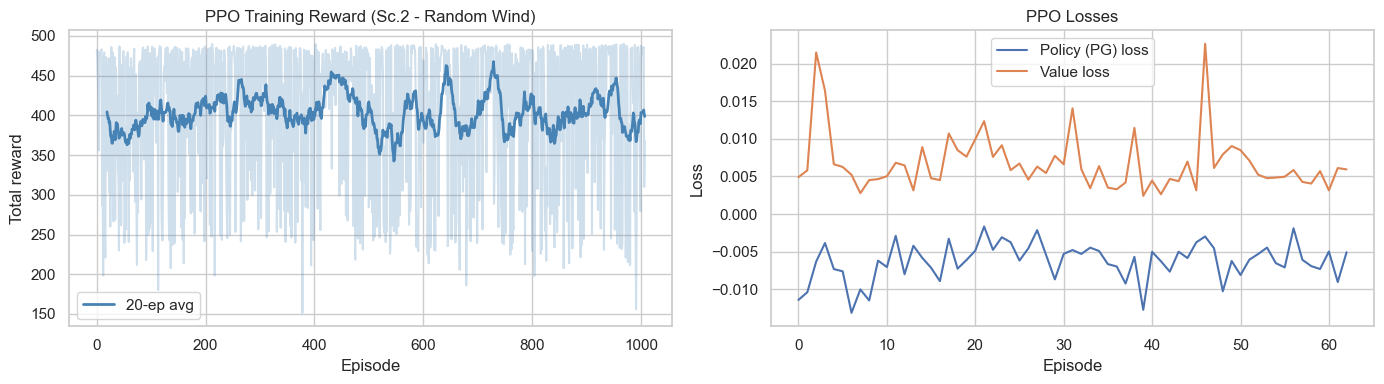

In [85]:
WINDOW   = 20
smoothed = np.convolve(episode_rewards, np.ones(WINDOW) / WINDOW, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(episode_rewards, alpha=0.25, color="steelblue")
ax.plot(np.arange(WINDOW - 1, len(episode_rewards)), smoothed,
        color="steelblue", linewidth=2, label=f"{WINDOW}-ep avg")
ax.set_xlabel("Episode")
ax.set_ylabel("Total reward")
ax.set_title("PPO Training Reward (Sc.2 - Random Wind)")
ax.legend()

ax = axes[1]
ax.plot(loss_log["pg"],  label="Policy (PG) loss")
ax.plot(loss_log["vf"],  label="Value loss")
ax.set_xlabel("Episode")
ax.set_ylabel("Loss")
ax.set_title("PPO Losses")
ax.legend()

plt.tight_layout()
plt.show()

## Evaluation: Greedy Policy Rollout

Run the trained policy deterministically (actor mean only, no sampling noise).

In [86]:
def evaluate_policy(n_episodes: int = 5, greedy: bool = True, seed_offset: int = 9001):
    """Return episode reward list and a DataFrame of the first episode's trajectory."""
    policy.eval()
    rewards   = []
    eval_rows = []

    with torch.no_grad():
        for ep in range(n_episodes):
            obs_dict = env_reset(seed_offset + ep, WIND_OPTS)
            done, total_r, step = False, 0.0, 0

            while not done:
                obs_np   = flatten_obs(obs_dict)
                obs_t    = torch.tensor(obs_np, dtype=torch.float32,
                                        device=DEVICE).unsqueeze(0)
                if greedy:
                    features = policy.actor_backbone(obs_t)
                    action_t = policy.actor_mean(features)
                else:
                    action_t = policy.act(obs_t)[0]
                # Clip to the actual action space bounds (not a hardcoded constant)
                action_np    = np.clip(
                    action_t.squeeze(0).cpu().numpy(),
                    env.action_space["yaw"].low,
                    env.action_space["yaw"].high,
                )
                joint_action = {"yaw": action_np}

                obs_dict, reward, termination, truncation, info = env.step(joint_action)
                r        = float(reward[0]) if hasattr(reward, "__len__") else float(reward)
                total_r += r

                if ep == 0:
                    eval_rows.append({
                        "step":   step,
                        "reward": r,
                        **{f"yaw_{i}":   obs_dict["yaw"][i]   for i in range(N_TURBINES)},
                        **{f"power_{i}": info["power"][i]     for i in range(N_TURBINES)},
                    })
                step += 1
                done = termination or truncation

            rewards.append(total_r)

    policy.train()
    return rewards, pd.DataFrame(eval_rows)


eval_rewards, eval_df = evaluate_policy(n_episodes=20)
print(f"Eval total rewards: {[f'{r:.2f}' for r in eval_rewards]}")
print(f"Mean +- std:  {np.mean(eval_rewards):.2f} +- {np.std(eval_rewards):.2f}")

Eval total rewards: ['489.80', '486.44', '391.55', '490.34', '389.48', '348.54', '487.98', '447.78', '244.04', '483.22', '490.06', '451.96', '487.50', '282.70', '489.43', '446.50', '489.83', '237.33', '480.36', '390.26']
Mean +- std:  425.25 +- 83.22


## Yaw Angles and Power Over a Representative Episode

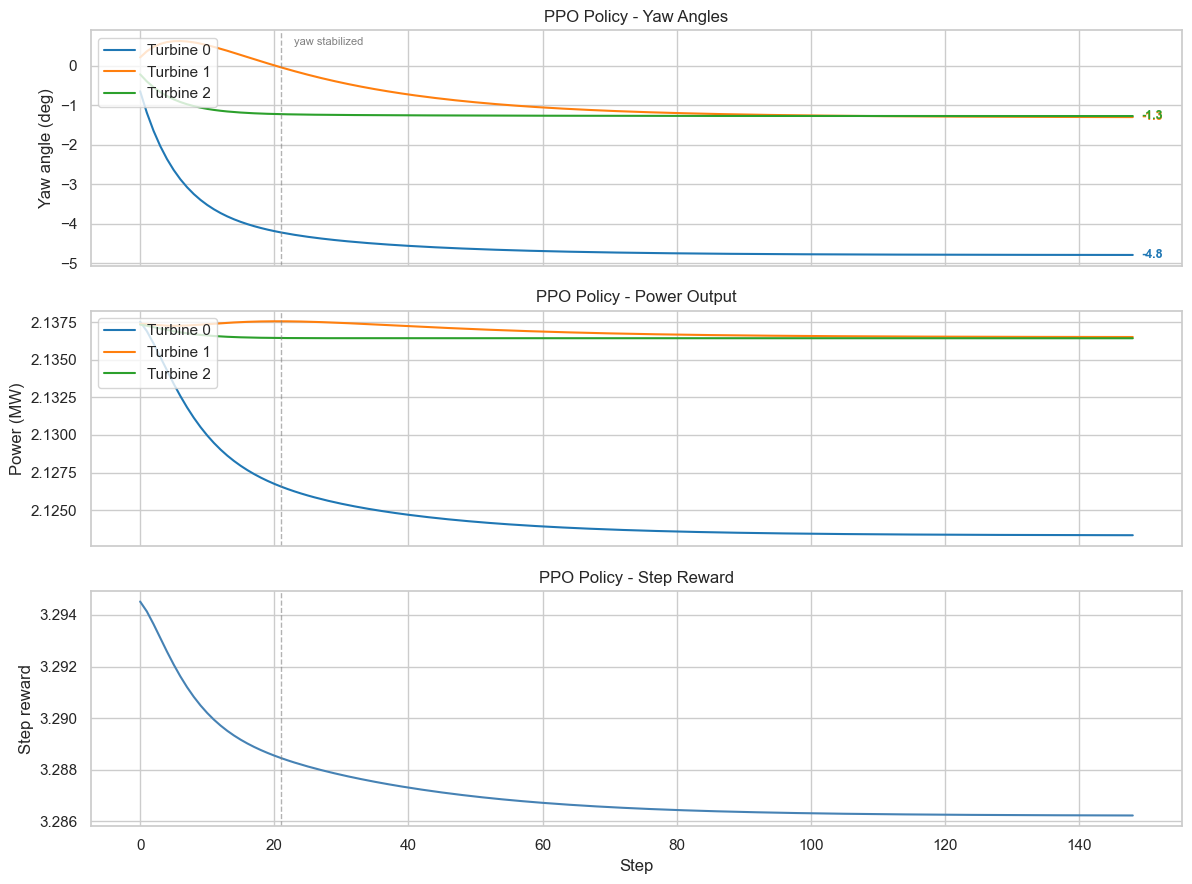

In [87]:
colors = sns.color_palette("tab10", N_TURBINES)
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# -- Yaw angles ----------------------------------------------------------------
ax = axes[0]
for i in range(N_TURBINES):
    ax.plot(eval_df["step"], eval_df[f"yaw_{i}"], color=colors[i], label=f"Turbine {i}")
    final_yaw  = eval_df[f"yaw_{i}"].iloc[-1]
    final_step = eval_df["step"].iloc[-1]
    ax.annotate(f"{final_yaw:.1f}",
                xy=(final_step, final_yaw),
                xytext=(6, 0), textcoords="offset points",
                color=colors[i], fontsize=9, va="center", fontweight="bold")
ax.set_ylabel("Yaw angle (deg)")
ax.set_title("PPO Policy - Yaw Angles")
ax.legend(loc="upper left")

# -- Power output --------------------------------------------------------------
ax = axes[1]
for i in range(N_TURBINES):
    ax.plot(eval_df["step"], eval_df[f"power_{i}"], color=colors[i], label=f"Turbine {i}")
ax.set_ylabel("Power (MW)")
ax.set_title("PPO Policy - Power Output")
ax.legend(loc="upper left")

# -- Step reward ---------------------------------------------------------------
ax = axes[2]
ax.plot(eval_df["step"], eval_df["reward"], color="steelblue", linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("Step reward")
ax.set_title("PPO Policy - Step Reward")

# -- Convergence marker: first step (after step 20) where rolling max yaw rate < 0.1 deg/step
yaw_rate = (
    eval_df[[f"yaw_{i}" for i in range(N_TURBINES)]]
    .diff().abs().max(axis=1)
    .rolling(10, min_periods=1).mean()
)
conv_candidates = eval_df["step"][(yaw_rate < 0.1) & (eval_df["step"] > 20)]
if not conv_candidates.empty:
    conv_step = int(conv_candidates.iloc[0])
    yaw_max = eval_df[[f"yaw_{i}" for i in range(N_TURBINES)]].values.max()
    for a in axes:
        a.axvline(conv_step, color="gray", linestyle="--", alpha=0.6, linewidth=1)
    axes[0].text(conv_step + 2, yaw_max * 0.85, "yaw stabilized", fontsize=8, color="gray")

plt.tight_layout()
plt.show()


## No-Control Baseline & Total Farm Power

Compare the PPO policy against a zero-action baseline (no yaw steering) on the same episodes. Total farm power = sum across all turbines, which is the actual metric the policy optimizes.

In [88]:
def evaluate_no_control(n_episodes: int = 5, seed_offset: int = 9001):
    """Baseline: always send zero yaw deltas (no steering applied)."""
    zero_action = {"yaw": np.zeros(N_TURBINES, dtype=np.float32)}
    rewards = []
    baseline_rows = []

    for ep in range(n_episodes):
        obs_dict = env_reset(seed_offset + ep, WIND_OPTS)
        done, total_r, step = False, 0.0, 0
        while not done:
            obs_dict, reward, termination, truncation, info = env.step(zero_action)
            r = float(reward[0]) if hasattr(reward, "__len__") else float(reward)
            total_r += r
            if ep == 0:
                baseline_rows.append({
                    "step": step,
                    "reward": r,
                    **{f"power_{i}": info["power"][i] for i in range(N_TURBINES)},
                })
            step += 1
            done = termination or truncation
        rewards.append(total_r)

    return rewards, pd.DataFrame(baseline_rows)


baseline_rewards, baseline_df = evaluate_no_control(n_episodes=20)

eval_df["total_power"]     = sum(eval_df[f"power_{i}"]     for i in range(N_TURBINES))
baseline_df["total_power"] = sum(baseline_df[f"power_{i}"] for i in range(N_TURBINES))

print(f"No-control rewards:  {[f'{r:.2f}' for r in baseline_rewards]}")
print(f"  Mean +- std: {np.mean(baseline_rewards):.2f} +- {np.std(baseline_rewards):.2f}")
print(f"PPO policy rewards:  {[f'{r:.2f}' for r in eval_rewards]}")
print(f"  Mean +- std: {np.mean(eval_rewards):.2f} +- {np.std(eval_rewards):.2f}")
gain_pct = (np.mean(eval_rewards) - np.mean(baseline_rewards)) / abs(np.mean(baseline_rewards)) * 100
print(f"\nPPO reward gain over no-control: {gain_pct:+.1f}%")

No-control rewards:  ['490.91', '486.44', '375.31', '491.84', '372.48', '358.47', '488.12', '446.05', '229.04', '482.90', '491.47', '449.87', '490.87', '251.20', '490.81', '439.39', '491.39', '266.97', '479.30', '372.94']
  Mean +- std: 422.29 +- 85.86
PPO policy rewards:  ['489.80', '486.44', '391.55', '490.34', '389.48', '348.54', '487.98', '447.78', '244.04', '483.22', '490.06', '451.96', '487.50', '282.70', '489.43', '446.50', '489.83', '237.33', '480.36', '390.26']
  Mean +- std: 425.25 +- 83.22

PPO reward gain over no-control: +0.7%


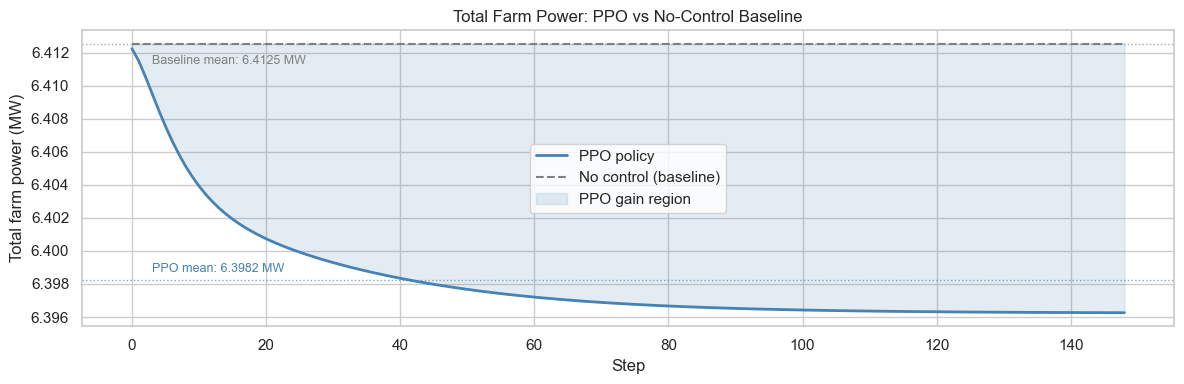

In [89]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(eval_df["step"], eval_df["total_power"],
        color="steelblue", linewidth=2, label="PPO policy")
ax.plot(baseline_df["step"], baseline_df["total_power"],
        color="gray", linestyle="--", linewidth=1.5, label="No control (baseline)")
ax.fill_between(eval_df["step"],
                baseline_df["total_power"], eval_df["total_power"],
                alpha=0.15, color="steelblue", label="PPO gain region")

mean_ppo  = eval_df["total_power"].mean()
mean_base = baseline_df["total_power"].mean()
ax.axhline(mean_ppo,  color="steelblue", linestyle=":", alpha=0.7, linewidth=1)
ax.axhline(mean_base, color="gray",      linestyle=":", alpha=0.7, linewidth=1)
x_label = eval_df["step"].iloc[-1] * 0.02
ax.text(x_label, mean_ppo  + 0.0005, f"PPO mean: {mean_ppo:.4f} MW",      color="steelblue", fontsize=9)
ax.text(x_label, mean_base - 0.0012, f"Baseline mean: {mean_base:.4f} MW", color="gray",      fontsize=9)

ax.set_xlabel("Step")
ax.set_ylabel("Total farm power (MW)")
ax.set_title("Total Farm Power: PPO vs No-Control Baseline")
ax.legend()
plt.tight_layout()
plt.show()


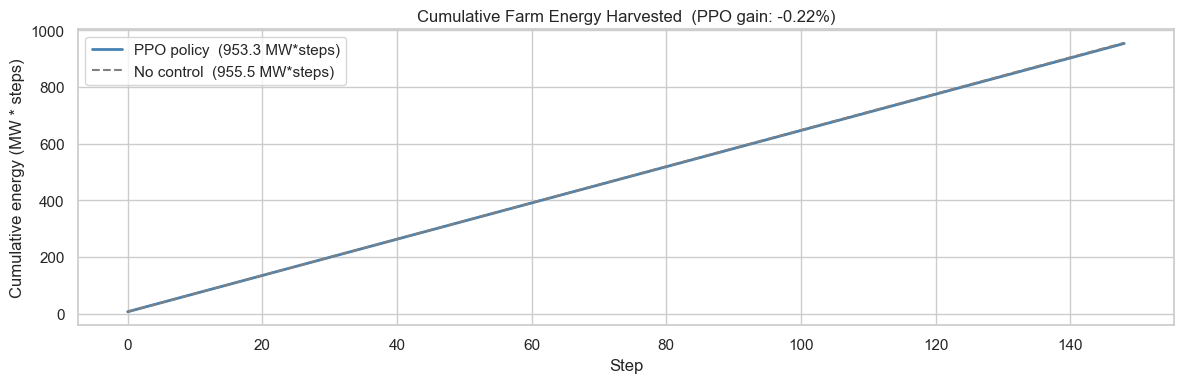

In [90]:
eval_df["cumulative_energy"]     = eval_df["total_power"].cumsum()
baseline_df["cumulative_energy"] = baseline_df["total_power"].cumsum()

final_ppo  = eval_df["cumulative_energy"].iloc[-1]
final_base = baseline_df["cumulative_energy"].iloc[-1]
gain_pct   = (final_ppo - final_base) / final_base * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(eval_df["step"], eval_df["cumulative_energy"],
        color="steelblue", linewidth=2,
        label=f"PPO policy  ({final_ppo:.1f} MW*steps)")
ax.plot(baseline_df["step"], baseline_df["cumulative_energy"],
        color="gray", linestyle="--", linewidth=1.5,
        label=f"No control  ({final_base:.1f} MW*steps)")
ax.fill_between(eval_df["step"],
                baseline_df["cumulative_energy"], eval_df["cumulative_energy"],
                alpha=0.15, color="steelblue")
ax.set_xlabel("Step")
ax.set_ylabel("Cumulative energy (MW * steps)")
ax.set_title(f"Cumulative Farm Energy Harvested  (PPO gain: {gain_pct:+.2f}%)")
ax.legend()
plt.tight_layout()
plt.show()


## Yaw Angle vs. Power Scatter

Each point is one step of the evaluated episode, colored by step number (dark = early, bright = late). Shows which yaw offsets the policy explored and the resulting power tradeoff per turbine.

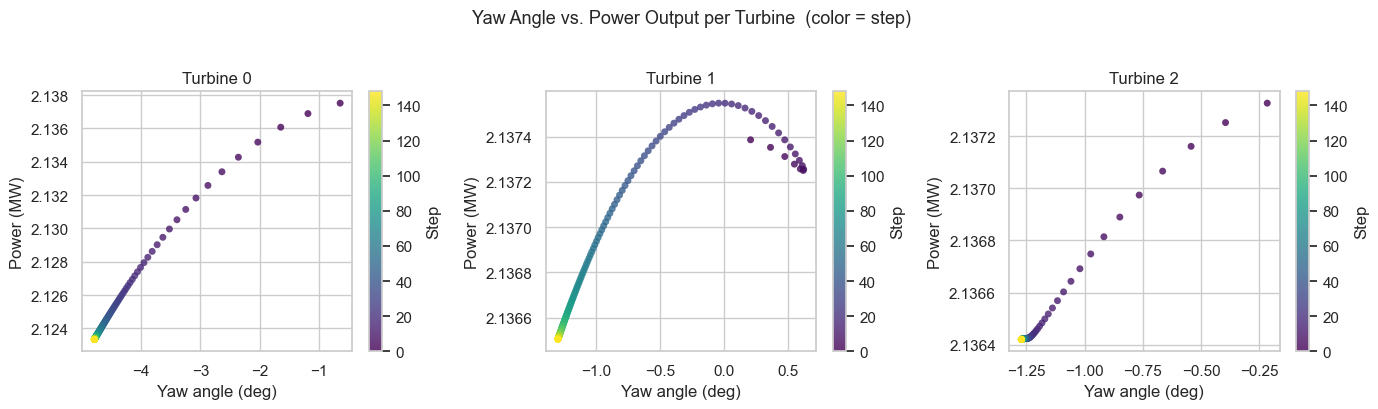

In [91]:
fig, axes = plt.subplots(1, N_TURBINES, figsize=(14, 4))

for i, ax in enumerate(axes):
    sc = ax.scatter(
        eval_df[f"yaw_{i}"], eval_df[f"power_{i}"],
        c=eval_df["step"], cmap="viridis", s=25, alpha=0.8, edgecolors="none",
    )
    ax.set_xlabel("Yaw angle (deg)")
    ax.set_ylabel("Power (MW)")
    ax.set_title(f"Turbine {i}")
    plt.colorbar(sc, ax=ax, label="Step")

plt.suptitle("Yaw Angle vs. Power Output per Turbine  (color = step)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


In [92]:

for i in range(N_TURBINES):
    print(f"{i}: {eval_df['step'].iloc[0]}, {eval_df[f'yaw_{i}'].iloc[0]}")

0: 0, -0.6445654034614563
1: 0, 0.2105448991060257
2: 0, -0.2165830284357071


In [93]:
# print the last step's yaw angles for each turbine
n_turbines = len([c for c in eval_df.columns if c.startswith("yaw_")])
for i in range(n_turbines):
    print(f"{i}: {eval_df['step'].iloc[-1]}, {eval_df[f'yaw_{i}'].iloc[-1]}")

0: 148, -4.7865753173828125
1: 148, -1.2983746528625488
2: 148, -1.2717804908752441


## Final Comparison

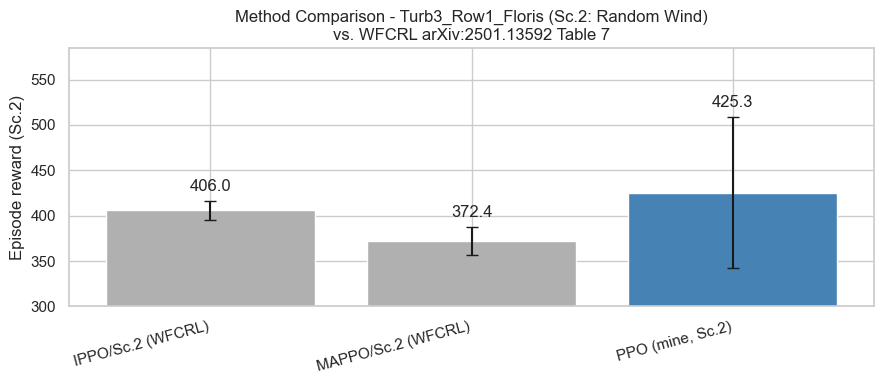


Summary (Sc.2 episode reward):
  Method                         Mean     Std
  IPPO/Sc.2 (WFCRL)             406.0    10.5
  MAPPO/Sc.2 (WFCRL)            372.4    15.5
  PPO (mine, Sc.2)              425.3    83.2 <-- mine


In [94]:
# WFCRL Table 7 reference results (Turb3_Row1_Floris, FLORIS, 200k steps, eval on Sc.2)
WFCRL_BASELINES = {
    "IPPO/Sc.2 (WFCRL)":  (406.0, 10.5),
    "MAPPO/Sc.2 (WFCRL)": (372.4, 15.5),
}

my_results = {
    "PPO (mine, Sc.2)": (np.mean(eval_rewards), np.std(eval_rewards)),
}

all_labels = list(WFCRL_BASELINES.keys()) + list(my_results.keys())
all_means  = [v[0] for v in WFCRL_BASELINES.values()] + [v[0] for v in my_results.values()]
all_errs   = [v[1] for v in WFCRL_BASELINES.values()] + [v[1] for v in my_results.values()]
colors     = ["#b0b0b0"] * len(WFCRL_BASELINES) + ["steelblue"]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(all_labels, all_means, yerr=all_errs, capsize=4, color=colors)
ax.bar_label(bars, labels=[f"{m:.1f}" for m in all_means], padding=5)
ax.set_ylabel("Episode reward (Sc.2)")
ax.set_title("Method Comparison - Turb3_Row1_Floris (Sc.2: Random Wind)\nvs. WFCRL arXiv:2501.13592 Table 7")
ax.set_ylim(300, max(m + e for m, e in zip(all_means, all_errs)) * 1.15)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

print("\nSummary (Sc.2 episode reward):")
print(f"  {'Method':<26s}  {'Mean':>7s}  {'Std':>6s}")
for label, (mean, std) in {**WFCRL_BASELINES, **my_results}.items():
    marker = " <-- mine" if "mine" in label else ""
    print(f"  {label:<26s}  {mean:>7.1f}  {std:>6.1f}{marker}")